In [1]:
!pip install pytorch-pretrained-biggan

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


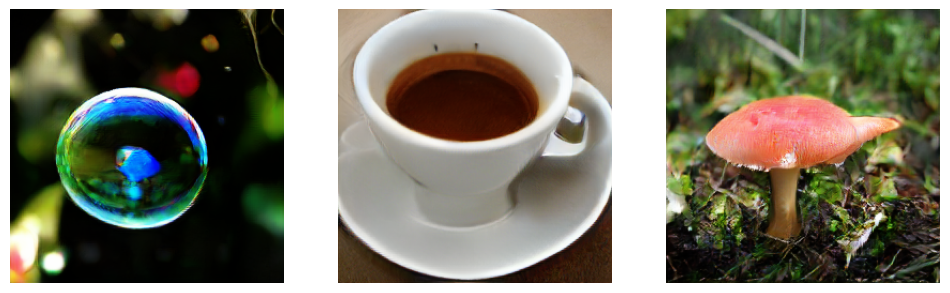

In [2]:
#git link>https://github.com/huggingface/pytorch-pretrained-BigGAN

import torch
from pytorch_pretrained_biggan import (BigGAN,one_hot_from_names,truncated_noise_sample,
                                       save_as_images, display_in_terminal)

# OPTIONAL: if you want to have more information on what's happening, activate the logger as follows
import logging
logging.basicConfig(level=logging.INFO)

import nltk
nltk.download('wordnet')

# Load pre-trained model tokenizer (vocabulary)
model = BigGAN.from_pretrained('biggan-deep-256')

# Prepare a input
truncation = 0.4
class_vector = one_hot_from_names(['soap_bubble','coffee','mushroom'],batch_size=3)
noise_vector = truncated_noise_sample(truncation=truncation,batch_size=3)

# All in tensors
noise_vector = torch.from_numpy(noise_vector)
class_vector = torch.from_numpy(class_vector)

# If we have a GPU, put everything on cuda
noise_vector = noise_vector.to('cuda')
class_vector = class_vector.to('cuda')
model.to('cuda')

# Generate an image
with torch.no_grad():
  output = model(noise_vector,class_vector,truncation)

# If we have a GPU put back on CPU
output = output.to('cpu')

# If you have a sixtel compatible terminal you can display the images in the terminal
# (see https://github.com/saitoha/libsixel for details)
#display_in_terminal(output)

# Save the results as ong image
save_as_images(output)

import matplotlib.pyplot as plt

# Display generated images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    image = output[i].permute(1, 2, 0).numpy()

    # BigGAN output is approximately in [-1, 1]
    image = (image + 1) / 2
    image = image.clip(0, 1)

    axes[i].imshow(image)
    axes[i].axis("off")

plt.show()